# Machine Learning Methods for Data Streams
## Project: Concept Drift Detection in Polarized News Streams

In [1]:
import random
import matplotlib.pyplot as plt
from river import compose, feature_extraction, naive_bayes, metrics, drift, utils

In [2]:
from synthetic_stream import SyntheticPoliticalStream

### 4. Synthetic Data Generation

This section focuses on creating a synthetic data stream that simulates the dynamics of polarized news articles.

The data is generated from vocabularies containing politically charged terms and neutral words. 

The generator works by creating articles as bags of words. Each one is labeled as either "Left" or "Right" based on the initial presence of words from the respective vocabularies.

The following concept drifts are simulated in the data stream:
- **Abrupt Drift**: A sudden change in the distribution of words, simulating a major political event or scandal.
- **Gradual Drift**: A slow shift in word usage over time, representing a cultural shift or changing public sentiment.
- **Recurring Concept**: A return to previous word distributions, simulating election cycles or recurring political themes.

The drift works by shifting words from one vocabulary to another, which changes the underlying concept of what constitutes "Left" or "Right" articles. Therefore it is a real drift.

The stream of articles is then feed into a model containing TF-IDF vectorizer and a Naive Bayes classifier, which is trained incrementally as new articles arrive.

Later, ADWIN is used to monitor the model's performance and detect any significant drops in accuracy, which would indicate a concept drift. The accuracy is calculated on a sliding window of recent predictions.

When a drift is detected, the model can be reset or left as is to observe how it adapts to the new concept.

In [3]:
def plot_shadow_models(steps, models_info, drifts_detected, drift_points):
    """Draws a multi-line chart comparing all generated models across multiple drifts."""
    print("\nGenerating the plot...")
    plt.figure(figsize=(14, 7))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    # Plot lines for each model
    for idx, info in enumerate(models_info):
        color = colors[idx % len(colors)]
        label = f"Model {idx+1} (Active from step {info['start_step']})"
        plt.plot(steps, info['accuracies'], label=label, color=color, linewidth=2.5)

    # Vertical lines for ADWIN alerts
    for i, d in enumerate(drifts_detected):
        label = 'ADWIN Alert & Reset' if i == 0 else ""
        plt.axvline(x=d, color='red', linestyle='--', alpha=0.8, label=label)

    # Vertical lines for actual drift injections
    for i, dp in enumerate(drift_points):
        label = 'Actual Drift Injection' if i == 0 else ""
        plt.axvline(x=dp, color='purple', linestyle='-', linewidth=2, label=label)

    plt.title('Synthetic Stream + ADWIN Drift Detector', fontsize=16, fontweight='bold')
    plt.xlabel('Number of processed articles (Time)', fontsize=12)
    plt.ylabel('Rolling Accuracy (Window=100)', fontsize=12)
    plt.ylim(0.0, 1.05)
    
    # Place the legend outside if there are too many models
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [4]:
def test_long_articles_generator(num_samples=5, min_len=20, max_len=50):
    generator = SyntheticPoliticalStream()
    
    # We only need a short stream for visual inspection
    test_stream = generator.get_stream(n_samples=num_samples, min_len=min_len, max_len=max_len)
    
    for i, (text, label) in enumerate(test_stream):
        class_name = "LEFT " if label == 0 else "RIGHT"
        words = text.split()
        actual_length = len(words)
        
        # Auditing the generated vocabulary
        left_count = sum(1 for w in words if w in generator.left_words)
        right_count = sum(1 for w in words if w in generator.right_words)
        neutral_count = sum(1 for w in words if w in generator.neutral_words)
        
        print(f"\n--- Sample {i+1} | True Class: {class_name} | Length: {actual_length} words ---")
        
        # Text wrapping for better readability in the console
        import textwrap
        wrapped_text = textwrap.fill(text, width=200)
        print(wrapped_text)
        
        # Print the audit stats
        print("-" * 80)
        print(f"Audit -> Left words: {left_count} | Right words: {right_count} | Neutral noise: {neutral_count}")

In [5]:
test_long_articles_generator(num_samples=3, min_len=30, max_len=100)


--- Sample 1 | True Class: RIGHT | Length: 59 words ---
global charter_schools police second_amendment century committee competition debt interview editorial systemic state deportation world development problem heritage recent document democracy industry
spending_cuts defense deregulation heritage job_creators traditional firearms independence headline revenue drill future publication national editorial infrastructure impact taxes renewable
charter_schools abortion defense fossil_fuels systemic editorial border veterans socialism population deportation fossil_fuels deportation transcript spending_cuts veterans sovereignty bridge security
--------------------------------------------------------------------------------
Audit -> Left words: 6 | Right words: 29 | Neutral noise: 25

--- Sample 2 | True Class: LEFT  | Length: 70 words ---
representative medicare voters nation infrastructure voting_rights official municipality economy environment racism interview second_amendment lgbtq healt

Starting the experiment...

Step 800: CONCEPT DRIFT INITIATED

Step 832: Concept Drift detected on Model 1
Creating New Model 2. Old model moved to shadow.

Step 1600: CONCEPT DRIFT INITIATED

Step 1633: Concept Drift detected on Model 2
Creating New Model 3. Old model moved to shadow.

Step 2400: CONCEPT DRIFT INITIATED

Step 2434: Concept Drift detected on Model 3
Creating New Model 4. Old model moved to shadow.

Generating the plot...


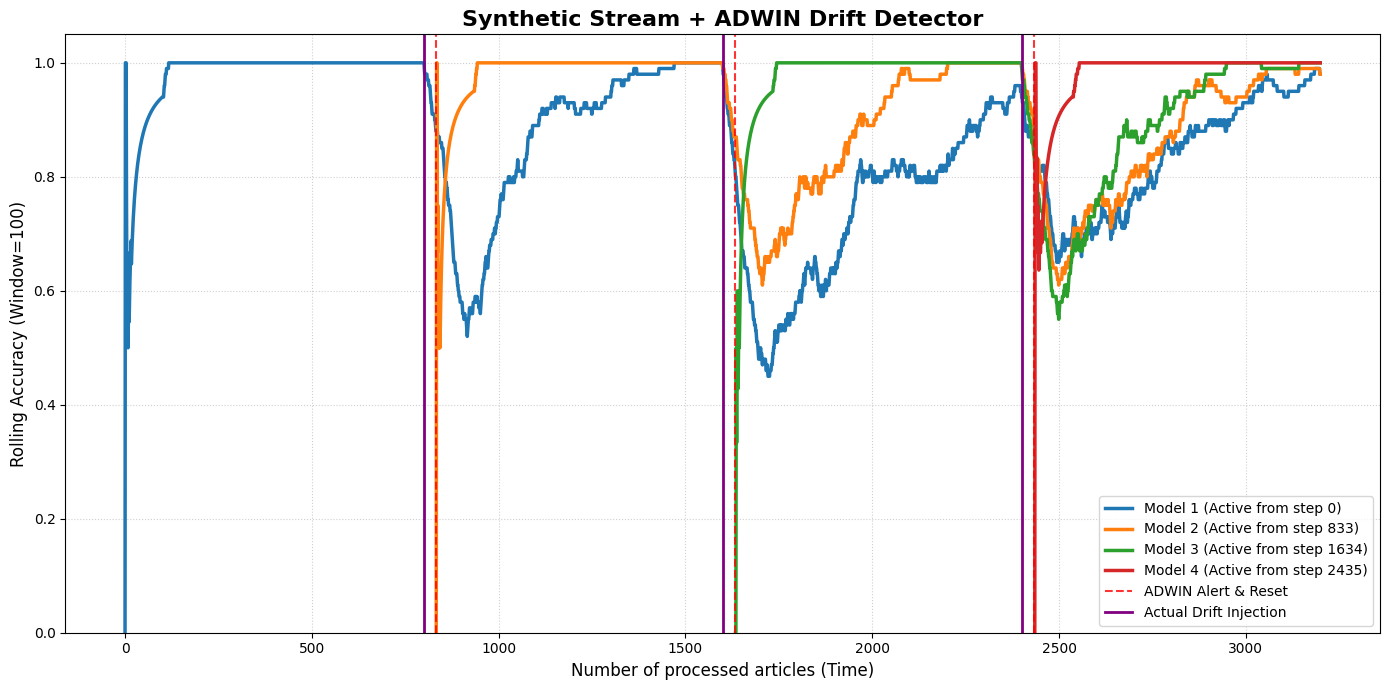

In [6]:
# ==========================================
# BASIC SIMULATION
# ==========================================
# Using stream_type='basic' with simple drift points
# Using train_strategy='all' to train all models (active + shadow)

points = [800, 1600, 2400]
total_samples = 3200

generator = SyntheticPoliticalStream(stream_type='basic', train_strategy='all')
my_stream = generator.get_stream(
    n_samples=total_samples, 
    drift_points=points, 
    drift_ratio=0.5,
    min_len=20, 
    max_len=50
)

steps, models_data, alerts = generator.run_adaptive_experiment(my_stream, reset_on_drift=True)
plot_shadow_models(steps, models_data, alerts, drift_points=points)

Starting the experiment...
SCHEDULED: Gradual Drift from 1500 to 2000 (Total 45 words)

Step 800: CONCEPT DRIFT INITIATED

Step 832: Concept Drift detected on Model 1
Creating New Model 2. Old model frozen as shadow.

Step 3000: RECURRING CONCEPT INITIATED

Step 3009: Concept Drift detected on Model 2
Creating New Model 3. Old model frozen as shadow.

Generating the plot...


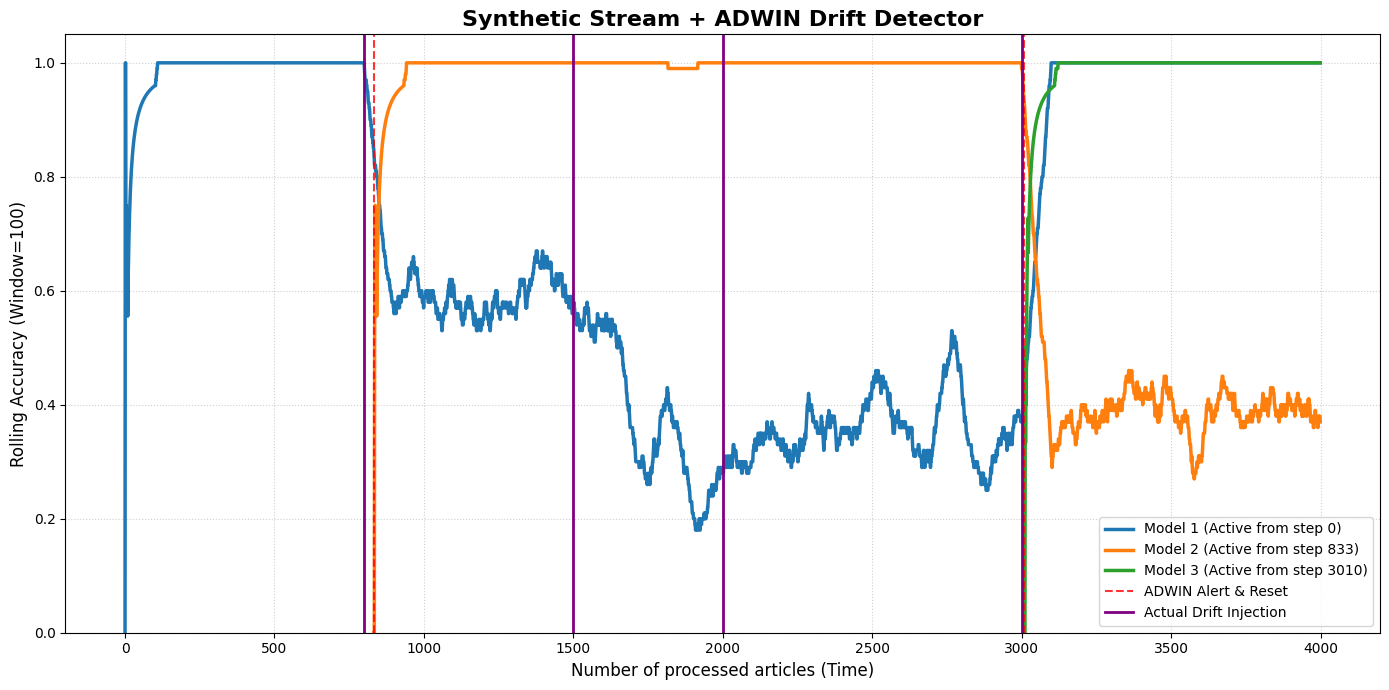

In [7]:

# ==========================================
# ADVANCED SIMULATION
# ==========================================
# Using stream_type='advanced' with multiple drift types
# Using train_strategy='active_only' to train only the active model (shadow models frozen)

total_samples = 4000
    
# Defining our narrative timeline:
# 1. Abrupt Drift at 800 (Sudden event, e.g., a scandal)
# 2. Gradual Drift 1500-2200 (Slow cultural shift over 700 articles)
# 3. Recurring Concept at 3000 (New election cycle starts, back to old slogans)
    
a_drifts = [(800, 0.5)]
g_drifts = [(1500, 2000, 0.9)] #percentage of swapped vocabulary by the end of the gradual drift period
r_drifts = [3000]
    
# We pass all these events to our new generator
generator = SyntheticPoliticalStream(stream_type='advanced', train_strategy='active_only')
my_stream = generator.get_stream(
    n_samples=total_samples, 
    abrupt_drifts=a_drifts, 
    gradual_drifts=g_drifts, 
    recurring_drifts=r_drifts,
    min_len=75, 
    max_len=100
)

plot_drift_markers = [800, 1500, 2000, 3000]

steps, models_data, alerts = generator.run_adaptive_experiment(my_stream, reset_on_drift=True)
    
plot_shadow_models(steps, models_data, alerts, drift_points=plot_drift_markers)